In [1]:
# Read in the anndata object
import anndata as ad
from pathlib import Path
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from scipy.stats import spearmanr, pearsonr
import scipy.sparse as sp
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.ticker import ScalarFormatter
import scanpy as sc
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from collections import defaultdict
import warnings
from adjustText import adjust_text

warnings.filterwarnings('ignore')

# Import LeafletFA differential splicing code
# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds

# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import *

# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
import sys
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

mouse_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
import sys
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

mouse_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


In [2]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

# Base directories
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
RESULTS_BASE_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results"

GE_ANNDATA_scVI_PATH = f"{BASE_DIR}/scVI/ge_adata_with_both_scvi_models_2025-08-03.h5ad"
GE_ANNDATA_NMF_PATH = f"{BASE_DIR}/NMF/ge_adata_with_NMF_standard_20_1024_2025-08-03.h5ad"

# Load GSEA scVI data (not using NMF anymore because clearly not capturing meaningful biological signal)
GSEA_scVI_PATH_nes = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/scvi_gsea_nes_matrix.tsv"
GSEA_scVI_PATH_es = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/scvi_gsea_es_matrix.tsv"
GSEA_full_scVI_PATH = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/gsea_results_comprehensive_scvi.tsv.gz"

# Load GSEA for NMF and PCA 
GSEA_NMF_PATH_nes = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/nmf_gsea_nes_matrix.tsv"
GSEA_NMF_PATH_es = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/nmf_gsea_es_matrix.tsv"
GSEA_full_NMF_PATH = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/gsea_results_comprehensive_nmf.tsv.gz"

# Load GSEA for PCA 
GSEA_PCA_PATH_nes = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/pca_gsea_nes_matrix.tsv"
GSEA_PCA_PATH_es = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/pca_gsea_es_matrix.tsv"
GSEA_full_PCA_PATH = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/GE_PLOTS/MOUSE/20250803/gsea_results_comprehensive_pca.tsv.gz"

# Load GSEA 
GSEA_scVI_nes = pd.read_csv(GSEA_scVI_PATH_nes, sep="\t")
GSEA_scVI_es = pd.read_csv(GSEA_scVI_PATH_es, sep="\t")
GSEA_scVI_full = pd.read_csv(GSEA_full_scVI_PATH, sep="\t")

GSEA_NMF_nes = pd.read_csv(GSEA_NMF_PATH_nes, sep="\t")
GSEA_NMF_es = pd.read_csv(GSEA_NMF_PATH_es, sep="\t")
GSEA_NMF_full = pd.read_csv(GSEA_full_NMF_PATH, sep="\t")

GSEA_PCA_nes = pd.read_csv(GSEA_PCA_PATH_nes, sep="\t")
GSEA_PCA_es = pd.read_csv(GSEA_PCA_PATH_es, sep="\t")
GSEA_PCA_full = pd.read_csv(GSEA_full_PCA_PATH, sep="\t")

# Reference files
AGING_GENES_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/27857814"
RBP_FILE_PATH = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"

ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"
)

# Load ATSE file
print(f"Loading ATSE file from {ATSE_FILE_PATH}")
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df["junction_annotation"] = "Novel_SS" 
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

# Load NMF data
ge_adata_nmf = ad.read_h5ad(GE_ANNDATA_NMF_PATH)
print(f"Done reading NMF anndata from {GE_ANNDATA_NMF_PATH}")

# Load scVI data
ge_adata = ad.read_h5ad(GE_ANNDATA_scVI_PATH)
print(ge_adata)
print(f"Done reading the ge_adata with scVI...")

assert np.all(ge_adata.obs_names == ge_adata_nmf.obs_names), "Cell IDs in ge_adata and ge_adata_nmf do not match or are not in the same order."
assert np.all(ge_adata.var_names == ge_adata_nmf.var_names), "Gene names in ge_adata and ge_adata_nmf do not match or are not in the same order."
ge_adata.obsm["X_nmf_standard_mb"] = ge_adata_nmf.obsm["X_nmf_standard_mb"]
ge_adata.varm["nmf_standard_mb_components"] = ge_adata_nmf.varm["nmf_standard_mb_components"]
# Add PCA loadings to ge_adata
ge_adata.obsm["X_pca"] = ge_adata_nmf.obsm["X_pca"]
ge_adata.varm["pca_loadings"] = ge_adata_nmf.varm["pca_loadings"]

print(f"Done combining gene expression into one object!")

# If ge_adata.var["gene_name"] is not in ge_adata.var_names, then add it
if "gene_name" not in ge_adata.var.columns:
    ge_adata.var["gene_name"] = ge_adata.var_names

# If ge_adata.obs doesn't have cell_id make it from cell_id_clean
if "cell_id" not in ge_adata.obs.columns:
    ge_adata.obs["cell_id"] = ge_adata.obs["cell_id_clean"]
 #   ge_adata_nmf.obs["cell_id"] = ge_adata_nmf.obs["cell_id_clean"]

Loading ATSE file from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz
Done reading NMF anndata from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/NMF/ge_adata_with_NMF_standard_20_1024_2025-08-03.h5ad
AnnData object with n_obs × n_vars = 137936 × 13394
    obs: 'cell_id', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'tissue', 'dataset', 'batch', 'subtissue_clean', 'broad_cell_type', 'cell_id_index', 'specific_cell_type', 'medium_cell_type', 'cell_name', 'library_size', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_is_rRNA', 'log1p_total_counts_is_rRNA', 'pct_counts_is_rRNA', 'nuclear_score_log_norm', 'nuclear_ratio_log_norm', 'nuclear_rrna_log_norm', 'nuclear_class_log_norm', 'nuclear_score_predicted_log_norm_tms', 'nuclear_ratio_predicted_log_norm_tms', 'nuclear_rr

In [3]:
# Load aging gene lists
aging_genes_mouse, aging_genes_human = load_aging_genes(AGING_GENES_PATH)
    
# Load RBP genes
rbps = load_rbp_genes(RBP_FILE_PATH)
rbps["mouse_gene_name"] = rbps["mouse_gene_name"].str.upper()
aging_genes_mouse = [g.upper() for g in aging_genes_mouse]

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
print(f"Renaming mouse.id to donor_id in splice_adata.obs")
# Update gene annotations
ge_adata.var["RBP_gene"] = ge_adata.var["gene_name"].isin(rbps["mouse_gene_name"])
ge_adata.var["Aging_gene"] = ge_adata.var["gene_name"].isin(aging_genes_mouse)
rbps = rbps["mouse_gene_name"]

Loaded 330 aging-related genes (mouse)
Loaded 330 aging-related genes (human)
Loaded 356 RNA binding proteins
Renaming mouse.id to donor_id in splice_adata.obs


In [4]:
# Main parameters to change
MODEL_TRAIN_DATE = "2025-08-01"
MODEL_ANALYSIS_DATE = "2025-08-03"
PARAM_ID = 0

# =============================================================================
# AUTO-GENERATED PATHS - DON'T EDIT BELOW THIS LINE
# =============================================================================

# Core result directories
PARAM_RESULTS_DIR = f"{RESULTS_BASE_DIR}/{MODEL_TRAIN_DATE}/{MODEL_ANALYSIS_DATE}/param_id_{PARAM_ID}"
DATA_DIR = f"{PARAM_RESULTS_DIR}/data"

# Model outputs
MODEL_OUTPUTS_DIR = f"{BASE_DIR}/Leaflet/leafletFAmodel/{MODEL_TRAIN_DATE}"
MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.xz"

# Main data files
SPLICE_ADATA_PATH = f"{DATA_DIR}/splice_adata_PHI_psi_var_obs.h5ad"
PI_VALUES_PATH = f"{DATA_DIR}/PI_values.npy"
PERPLEXITY_PATH =  f"{DATA_DIR}/cell_metadata_with_perplexity_param_id_{PARAM_ID}.csv.gz"
DIFF_SPL_PATH = f"{DATA_DIR}/differential_splicing_results.csv"

# Output directory for current analysis
OUTPUT_DIR = f"{PARAM_RESULTS_DIR}/analysis_outputs"

# =============================================================================
# LOAD DATA USING CONFIGURED PATHS
# =============================================================================

print(f"Loading data for param_id {PARAM_ID} from {MODEL_TRAIN_DATE}")
print(f"Data directory: {DATA_DIR}")

# Load main datasets
splice_adata = ad.read_h5ad(SPLICE_ADATA_PATH)
assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values), "Cell IDs in ge_adata and splice_adata do not match or are not in the same order."

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
if "mouse.id" in splice_adata.obs.columns:
    print(f"Renaming mouse.id to donor_id in splice_adata.obs")
    splice_adata.obs.rename(columns={"mouse.id": "donor_id"}, inplace=True)

# Fix the sex column in the anndatas
sex_str = splice_adata.obs["sex"].astype(str)

# Step 2: Replace "M" → "male", "F" → "female"
sex_fixed = sex_str.replace({"M": "male", "F": "female"})

# Step 3: Convert back to categorical (optional)
splice_adata.obs["sex"] = pd.Categorical(sex_fixed)
print(splice_adata.obs["sex"].value_counts())

pi = np.load(PI_VALUES_PATH)
diff_spl = pd.read_csv(DIFF_SPL_PATH)
perplexity_df = pd.read_csv(PERPLEXITY_PATH)
perplexity_df = perplexity_df.set_index("cell_id")
leaflet_model = load_model(MODEL_PATH)

splice_adata.obs_names = splice_adata.obs["cell_id"]
assert all(splice_adata.obs_names == perplexity_df.index), "Cell IDs in filtered_splice_adata and perplexity_df do not match or are not in the same order"
splice_adata.obs["perplexity"] = perplexity_df["perplexity"]

print(f"Loaded splice_adata: {splice_adata.shape}")
print(f"Loaded PI values: {pi.shape}")
print(f"Loaded diff_spl: {diff_spl.shape}")

MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.xz"
leaflet_model = load_model(MODEL_PATH)

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Loading data for param_id 0 from 2025-08-01
Data directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-08-01/2025-08-03/param_id_0/data
sex
male      85461
female    52475
Name: count, dtype: int64
Loading model to device: cpu
Loaded splice_adata: (137936, 26212)
Loaded PI values: (20,)
Loaded diff_spl: (60056, 44)
Loading model to device: cpu
Output directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-08-01/2025-08-03/param_id_0/analysis_outputs


In [5]:
# Always assert after creation or reuse
assert all(splice_adata.obs_names == ge_adata.obs_names)
splice_adata.obs["AgingScore_unweighted"] = ge_adata.obs["AgingScore_unweighted"]
splice_adata.obs["total_counts"] = ge_adata.obs["total_counts"]
splice_adata.obs["nuclear_class_log_norm"] = ge_adata.obs["nuclear_class_log_norm"]
splice_adata.obs["nuclear_score_log_norm"] = ge_adata.obs["nuclear_score_log_norm"]

In [6]:
# Number of factors (K)
K = splice_adata.obsm["X_PHI"].shape[1]

# Get new factor order (indices sorted by decreasing PI)
new_order = np.argsort(-pi)  # minus for descending sort

# Print sorted pi with original indices
print("Sorted pi values with original factor indices:")
for rank, idx in enumerate(new_order):
    print(f"Rank {rank + 1}: Factor {idx} → PI = {pi[idx]:.4f}")

old_to_new_factor_idx = {old: new for new, old in enumerate(new_order)}
print(old_to_new_factor_idx)

# Reorder X_PHI (cell × K)
splice_adata.obsm["X_PHI"] = splice_adata.obsm["X_PHI"][:, new_order]

# Reorder psi_learned (junction × K)
splice_adata.varm["psi_learned"] = splice_adata.varm["psi_learned"][:, new_order]

# Generate column names: SP_1, SP_2, ..., SP_K
phi_colnames = [f"SP_{i+1}" for i in range(K)]

# Create a DataFrame from X_PHI
phi_df = pd.DataFrame(
    splice_adata.obsm["X_PHI"], 
    index=splice_adata.obs_names,
    columns=phi_colnames
)

# Merge with adata.obs
splice_adata.obs = pd.concat([splice_adata.obs, phi_df], axis=1)

# Step 2: Rename and map
diff_spl = diff_spl.rename(columns={"factor_idx": "old_factor_idx"})
diff_spl["factor_idx"] = diff_spl["old_factor_idx"].map(old_to_new_factor_idx)

Sorted pi values with original factor indices:
Rank 1: Factor 1 → PI = 0.1581
Rank 2: Factor 4 → PI = 0.0968
Rank 3: Factor 3 → PI = 0.0967
Rank 4: Factor 10 → PI = 0.0760
Rank 5: Factor 0 → PI = 0.0596
Rank 6: Factor 5 → PI = 0.0565
Rank 7: Factor 12 → PI = 0.0533
Rank 8: Factor 7 → PI = 0.0473
Rank 9: Factor 11 → PI = 0.0412
Rank 10: Factor 2 → PI = 0.0402
Rank 11: Factor 8 → PI = 0.0382
Rank 12: Factor 9 → PI = 0.0366
Rank 13: Factor 14 → PI = 0.0350
Rank 14: Factor 6 → PI = 0.0335
Rank 15: Factor 15 → PI = 0.0316
Rank 16: Factor 13 → PI = 0.0269
Rank 17: Factor 16 → PI = 0.0198
Rank 18: Factor 18 → PI = 0.0184
Rank 19: Factor 17 → PI = 0.0175
Rank 20: Factor 19 → PI = 0.0167
{1: 0, 4: 1, 3: 2, 10: 3, 0: 4, 5: 5, 12: 6, 7: 7, 11: 8, 2: 9, 8: 10, 9: 11, 14: 12, 6: 13, 15: 14, 13: 15, 16: 16, 18: 17, 17: 18, 19: 19}


In [7]:
# Clean up Broad Cell Type column
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"].str.title()
splice_adata.obs["age_numeric"] = splice_adata.obs["age_numeric"]
splice_adata.obs["broad_cell_type"] = splice_adata.obs["broad_cell_type"]

In [8]:
# Step 2: Reindex to match AnnData.obs_names (i.e., cell IDs)
perplexity_df = perplexity_df.reindex(splice_adata.obs_names)

# Step 3: Add as a new column in AnnData.obs
splice_adata.obs["perplexity"] = perplexity_df["perplexity"].values

# Step 4: Filter medium_cell_types with >= 50 cells
valid_medium_ct = (
    splice_adata.obs["medium_cell_type"]
    .value_counts()[lambda x: x >= 50]
    .index
)

# Subset AnnData object to only those cells
splice_adata = splice_adata[splice_adata.obs["medium_cell_type"].isin(valid_medium_ct)].copy()

# Ensure ge_adata is subsetted to match
ge_adata = ge_adata[ge_adata.obs["medium_cell_type"].isin(valid_medium_ct)].copy()

# Assert order of cells is the same
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

Creating simple age vs cell type heatmap...
Data shape: (57, 4)
Age range: 2 - 24 months


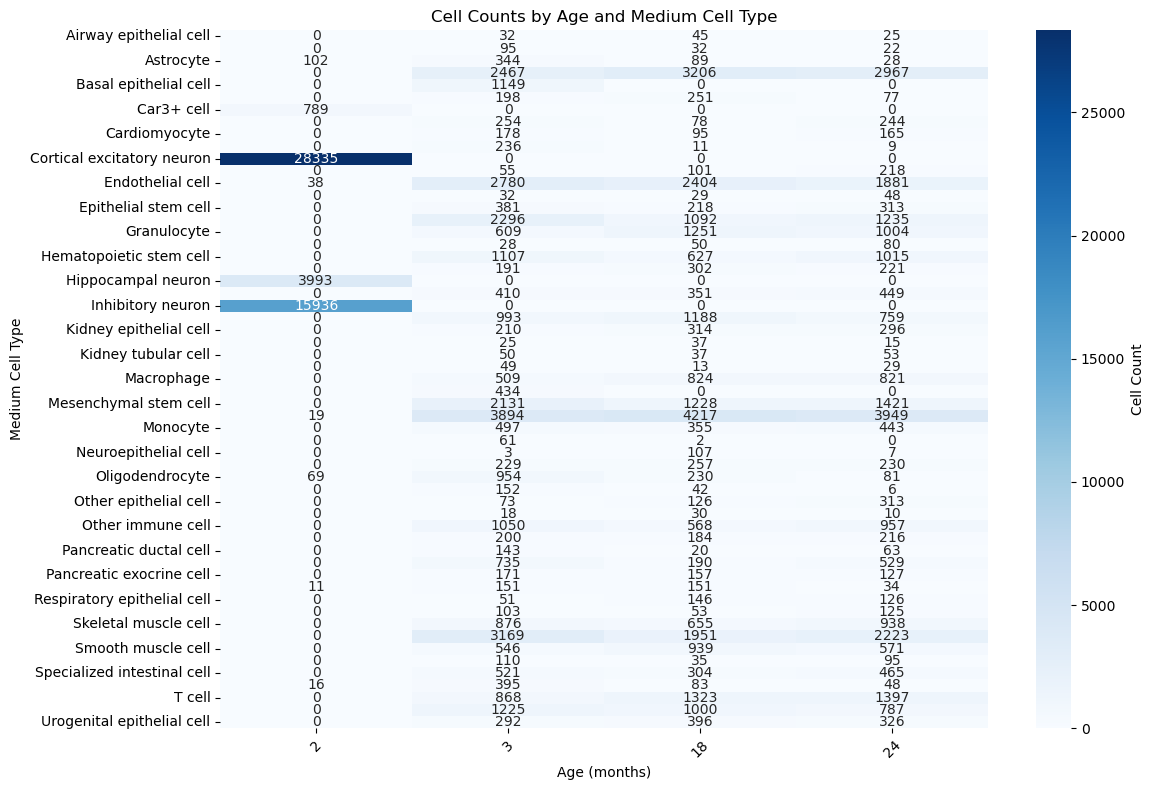

<Figure size 640x480 with 0 Axes>

In [9]:
# summarize cell type versus age numeric heatmap 
# add code here 
# Simple heatmap of medium_cell_type vs age_numeric
print("Creating simple age vs cell type heatmap...")

# Create crosstab for heatmap
heatmap_data = pd.crosstab(
    splice_adata.obs['medium_cell_type'], 
    splice_adata.obs['age_numeric']
).fillna(0)

print(f"Data shape: {heatmap_data.shape}")
print(f"Age range: {splice_adata.obs['age_numeric'].min()} - {splice_adata.obs['age_numeric'].max()} months")

# Create simple heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='g', 
            cmap='Blues',
            cbar_kws={'label': 'Cell Count'})
plt.title('Cell Counts by Age and Medium Cell Type')
plt.xlabel('Age (months)')
plt.ylabel('Medium Cell Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save the plot
plt.savefig(f"{OUTPUT_DIR}/simple_age_vs_celltype_heatmap.pdf", bbox_inches='tight')

In [10]:
splice_adata

AnnData object with n_obs × n_vars = 137893 × 26212
    obs: 'cell_id_index', 'age', 'cell_ontology_class', 'donor_id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'specific_cell_type', 'broad_cell_type', 'medium_cell_type', 'seqtech', 'library_size', 'total_junction_reads', 'annotated_junction_reads', 'unannotated_junction_reads', 'n_detected_annotated_junctions', 'n_detected_unannotated_junctions', 'AgingScore_unweighted', 'AgingScore_pos', 'AgingScore_neg', 'nuclear_ratio_log_norm', 'age_numeric', 'age_group', 'perplexity', 'total_counts', 'nuclear_class_log_norm', 'nuclear_score_log_norm', 'SP_1', 'SP_2', 'SP_3', 'SP_4', 'SP_5', 'SP_6', 'SP_7', 'SP_8', 'SP_9', 'SP_10', 'SP_11', 'SP_12', 'SP_13', 'SP_14', 'SP_15', 'SP_16', 'SP_17', 'SP_18', 'SP_19', 'SP_20'
    var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'n_cells_detected'

In [11]:
# assert ge_adata.obs_names == splice_adata.obs_names for all cells 
all(ge_adata.obs_names == splice_adata.obs_names)

True

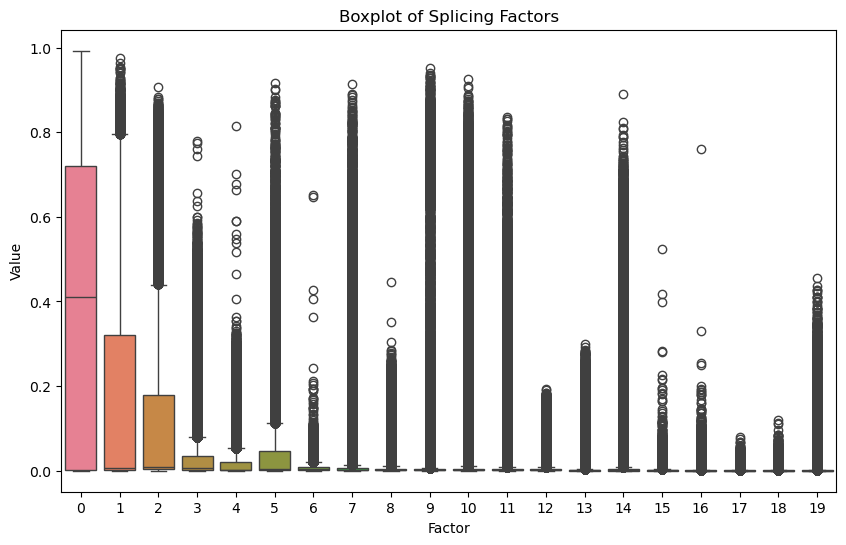

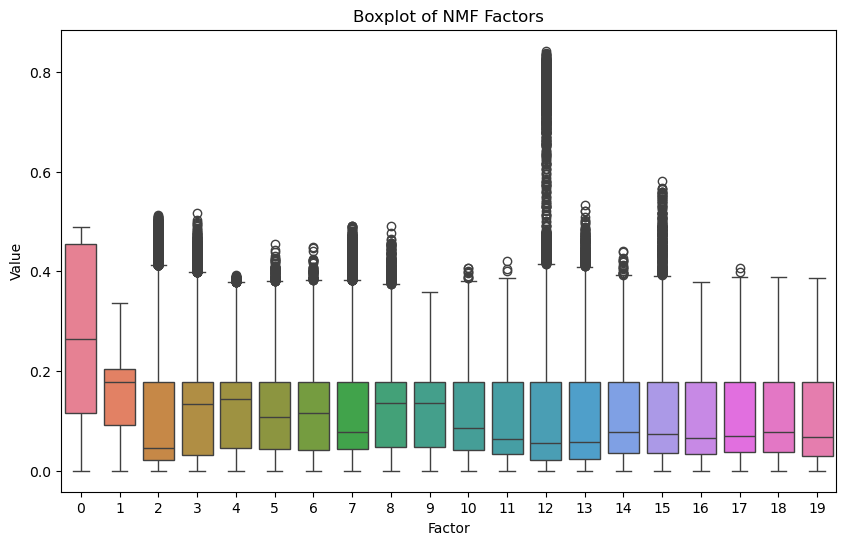

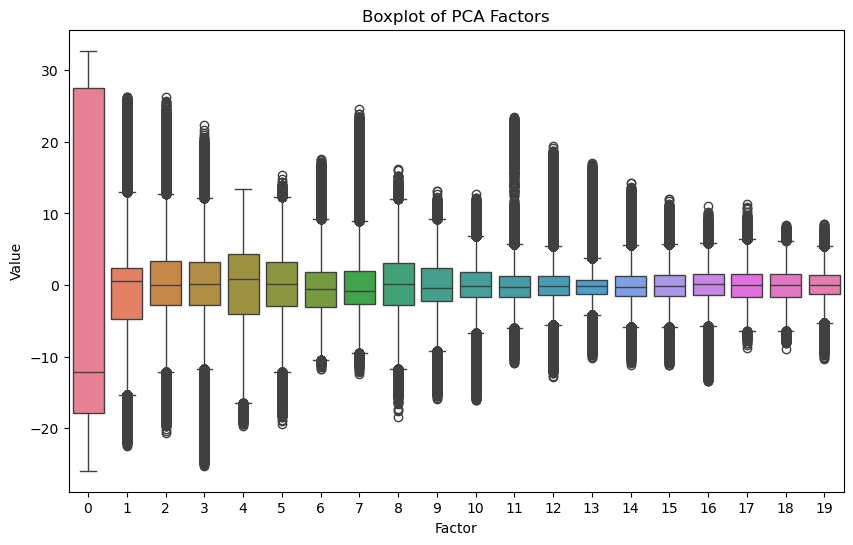

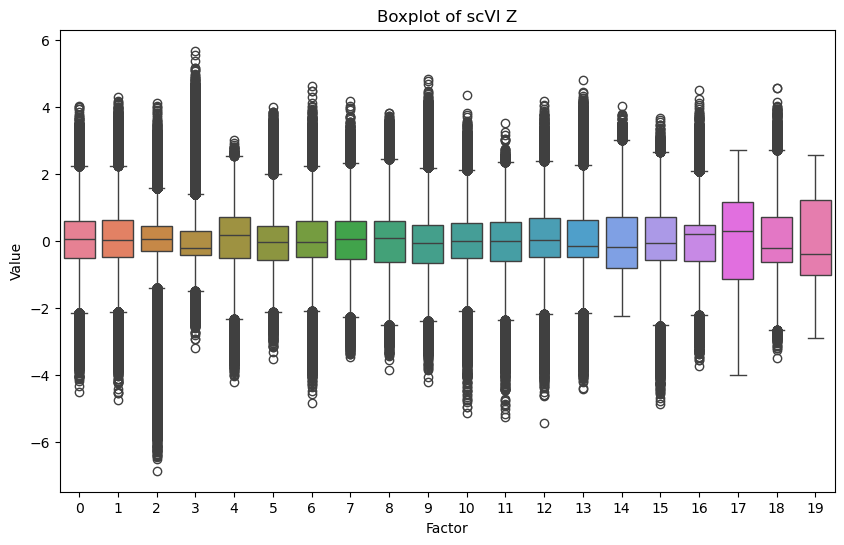

In [12]:
# Extract features (cells are in same order)
dirichlet_feat = splice_adata.obsm["X_PHI"]  # Splicing features (K=20)
scvi_feat = ge_adata.obsm["X_scVI_linear"]   # Gene expression features
nmf_feat = ge_adata.obsm["X_nmf_standard_mb"]
pca_feat = ge_adata.obsm["X_pca"]

# Plot boxplots of dirichlet_feat, one box per factor 
plt.figure(figsize=(10, 6))
sns.boxplot(data=dirichlet_feat)
plt.title('Boxplot of Splicing Factors')
plt.xlabel('Factor')
plt.ylabel('Value')
plt.show()

# Plot boxplots of nmf_feat, one box per factor 
plt.figure(figsize=(10, 6))
sns.boxplot(data=nmf_feat)
plt.title('Boxplot of NMF Factors')
plt.xlabel('Factor')
plt.ylabel('Value')
plt.show()

# Plot boxplots of pca_feat, one box per factor 
plt.figure(figsize=(10, 6))
sns.boxplot(data=pca_feat)
plt.title('Boxplot of PCA Factors')
plt.xlabel('Factor')
plt.ylabel('Value')
plt.show()

# Plot boxplots of dirichlet_feat, one box per factor 
plt.figure(figsize=(10, 6))
sns.boxplot(data=scvi_feat)
plt.title('Boxplot of scVI Z')
plt.xlabel('Factor')
plt.ylabel('Value')
plt.show()

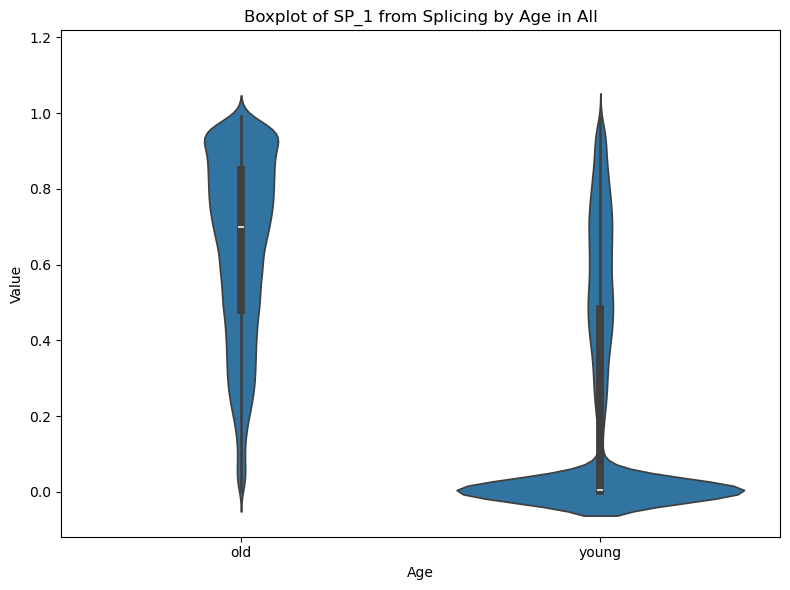

In [13]:
sp = "SP_1"
tissue = "All"
#plot_data = splice_adata.obs[splice_adata.obs["tissue"] == tissue]
plot_data = splice_adata.obs

# Create the boxenplot
plt.figure(figsize=(8, 6))
sns.violinplot(x="age_group", y=sp, data=plot_data)
plt.title(f'Boxplot of {sp} from Splicing by Age in {tissue}')
plt.xlabel('Age')
plt.ylabel('Value')

# Get the unique ages and their order in the plot
unique_ages = sorted(splice_adata.obs["age_numeric"].unique())

# Adjust y-axis to make room for text
plt.ylim(plt.ylim()[0], plt.ylim()[1] * 1.1)

plt.tight_layout()
plt.show()

## Summarize top GSEA pathway per NMF, PCA and scVI dimension

In [14]:
# go through every column in NMF, PCA and scVI and report top positive pathway for each column  
NMF_pathways = {}
PCA_pathways = {}
scVI_pathways = {}

for col in GSEA_NMF_nes.columns:
    # Skip very first column    
    if col == "Unnamed: 0":
        continue
    # sort by ES in column descending order, if no pathways with ES >- report no pathway 
    sorted_es = GSEA_NMF_nes.sort_values(by=col, ascending=False)
    if sorted_es[col].iloc[0] < 0:
        print("No pathways with ES > 0")
        NMF_pathways[col] = "NoPathways"
    else:
        # Join the top 3 pathways into a single string
        NMF_pathways[col] = ', '.join(sorted_es.head(2)["Unnamed: 0"].values)

for col in GSEA_PCA_nes.columns:
    # Skip very first column    
    if col == "Unnamed: 0":
        continue
    sorted_es = GSEA_PCA_nes.sort_values(by=col, ascending=False)
    if sorted_es[col].iloc[0] < 0:
        print("No pathways with ES > 0")
        PCA_pathways[col] = "NoPathways"
    else:
        # Join the top 3 pathways into a single string
        PCA_pathways[col] = ', '.join(sorted_es.head(2)["Unnamed: 0"].values)

for col in GSEA_scVI_nes.columns:
    # Skip very first column    
    if col == "Unnamed: 0":
        continue
    sorted_es = GSEA_scVI_nes.sort_values(by=col, ascending=False)
    if sorted_es[col].iloc[0] < 0:
        print("No pathways with ES > 0")
        scVI_pathways[col] = "NoPathways"
    else:
        # Join the top 3 pathways into a single string
        scVI_pathways[col] = ', '.join(sorted_es.head(2)["Unnamed: 0"].values)

# report dataframe with NMF_pathways
# column 1 = NMF and column 2 is pathway 
NMF_pathways_nes_df = pd.DataFrame(NMF_pathways, index=["pathway"]).T
NMF_pathways_nes_df["method"] = "NMF"
NMF_pathways_nes_df["factor"] = NMF_pathways_nes_df.index
PCA_pathways_nes_df = pd.DataFrame(PCA_pathways, index=["pathway"]).T
PCA_pathways_nes_df["method"] = "PCA"
PCA_pathways_nes_df["factor"] = PCA_pathways_nes_df.index
scVI_pathways_nes_df = pd.DataFrame(scVI_pathways, index=["pathway"]).T
scVI_pathways_nes_df["method"] = "scVI"
scVI_pathways_nes_df["factor"] = scVI_pathways_nes_df.index

## Compare silouette scores and classification of broad and medium cell types across NMF, PCA and scVI low dim space 

In [16]:
# import RidgeCV 

from sklearn.linear_model import RidgeCV

def run_simple_tissue_ridge(splice_adata, ge_adata, covariate="tissue", 
                            alphas=np.logspace(-2, 3, 20)):
    """
    Simple ridge regression by tissue - fit on all data, get single R².
    Much cleaner than problematic CV approach.
    """
    # Extract features
    assert all(splice_adata.obs_names == ge_adata.obs_names)
    
    dirichlet_data = splice_adata.obsm["X_PHI"]
    scvi_data = ge_adata.obsm["X_scVI_linear"] 
    age = splice_adata.obs['age_numeric'].values
    
    results = {}
    
    for tissue in tqdm(splice_adata.obs[covariate].unique()):
        mask = (splice_adata.obs[covariate] == tissue).values
        if mask.sum() < 100 or len(np.unique(age[mask])) == 1:
            continue
            
        # Get tissue-specific data
        X_sp = StandardScaler().fit_transform(dirichlet_data[mask])
        X_sc = StandardScaler().fit_transform(scvi_data[mask])
        X_comb = np.hstack([X_sp, X_sc])
        y = age[mask]
        
        # Fit models with cross-validated alpha selection
        ridge_sp = RidgeCV(alphas=alphas, cv=5).fit(X_sp, y)
        ridge_sc = RidgeCV(alphas=alphas, cv=5).fit(X_sc, y) 
        ridge_comb = RidgeCV(alphas=alphas, cv=5).fit(X_comb, y)
        
        # Get R² on full data (much more stable!)
        r2_sp = ridge_sp.score(X_sp, y)
        r2_sc = ridge_sc.score(X_sc, y)
        r2_comb = ridge_comb.score(X_comb, y)
        
        # F-test for significance
        n = len(y)
        rss_sp = np.sum((y - ridge_sp.predict(X_sp))**2)
        rss_sc = np.sum((y - ridge_sc.predict(X_sc))**2)
        rss_comb = np.sum((y - ridge_comb.predict(X_comb))**2)
        
        # Test combined vs individual models
        f_vs_sp = ((rss_sp - rss_comb) / X_sc.shape[1]) / (rss_comb / (n - X_sp.shape[1] - X_sc.shape[1] - 1))
        p_vs_sp = 1 - stats.f.cdf(f_vs_sp, X_sc.shape[1], n - X_sp.shape[1] - X_sc.shape[1] - 1)
        
        f_vs_sc = ((rss_sc - rss_comb) / X_sp.shape[1]) / (rss_comb / (n - X_sp.shape[1] - X_sc.shape[1] - 1))
        p_vs_sc = 1 - stats.f.cdf(f_vs_sc, X_sp.shape[1], n - X_sp.shape[1] - X_sc.shape[1] - 1)
        
        results[tissue] = {
            'n_cells': mask.sum(),
            'splice_r2': r2_sp,
            'scvi_r2': r2_sc, 
            'combined_r2': r2_comb,
            'p_combined_vs_splice': p_vs_sp,
            'p_combined_vs_scvi': p_vs_sc
        }
    
    return results

# Run the cleaner analysis
results = run_simple_tissue_ridge(splice_adata, ge_adata, covariate="medium_cell_type")

100%|██████████| 57/57 [02:13<00:00,  2.35s/it]


In [17]:
# Create summary DataFrame
summary_data = []
for tissue, res in results.items():
    summary_data.append({
        'tissue': tissue,
        'n_cells': res['n_cells'],
        'LeafletFA_r2': res['splice_r2'],
        'scVI_r2': res['scvi_r2'],
        'LeafletFA_scVI_r2': res['combined_r2'],
        'p_combined_vs_LeafletFA': res['p_combined_vs_splice'],
        'p_combined_vs_scVI': res['p_combined_vs_scvi']
    })

summary_df = pd.DataFrame(summary_data)

# Simple, clean plot
summary_df_sorted = summary_df.sort_values('LeafletFA_r2', ascending=False)
tissues = summary_df_sorted['tissue'].values
models = ['LeafletFA', 'scVI', 'LeafletFA_scVI']

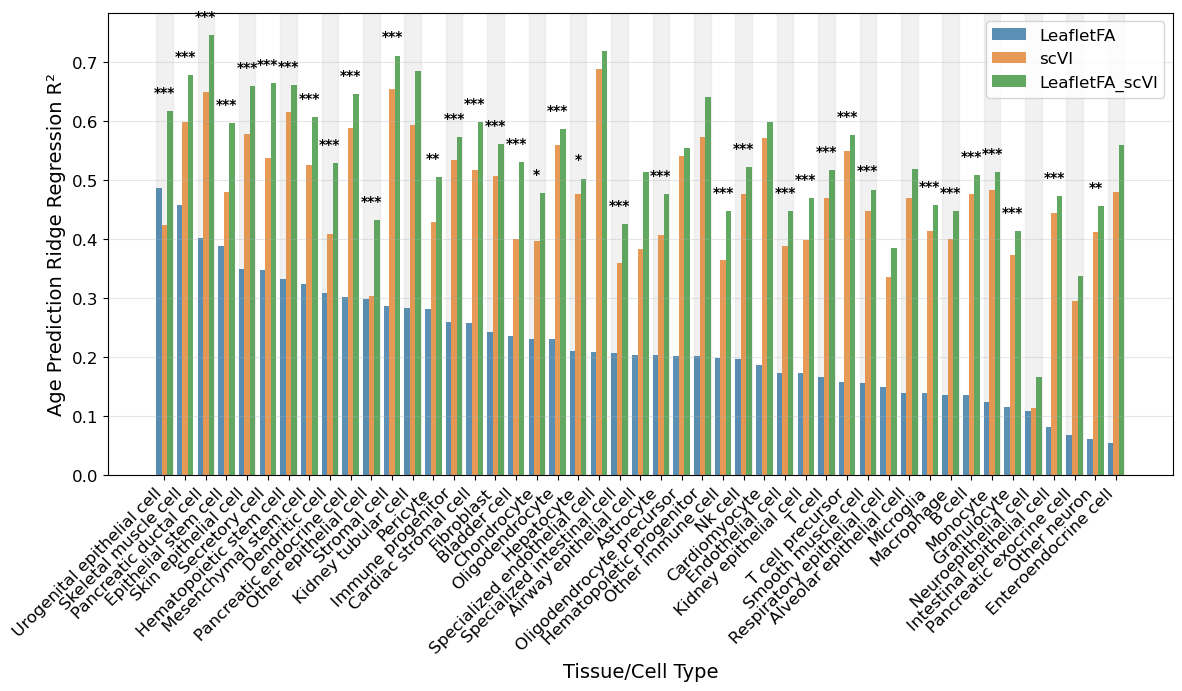

Saved plot to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-08-01/2025-08-03/param_id_0/analysis_outputs/age_prediction_performance.pdf


In [18]:
import seaborn as sns
from statsmodels.stats.multitest import multipletests

# FDR correction
summary_df_sorted["p_combined_vs_scVI_fdr"] = multipletests(summary_df_sorted["p_combined_vs_scVI"], method="fdr_bh")[1]

# Reshape data for seaborn
plot_data = []
for _, row in summary_df_sorted.iterrows():
    for model in ['LeafletFA', 'scVI', 'LeafletFA_scVI']:
        plot_data.append({
            'tissue': row['tissue'],
            'model': model,
            'r2': row[f'{model}_r2']
        })

plot_df = pd.DataFrame(plot_data)

# Create plot
fig, ax = plt.subplots(figsize=(12, 7))

# Seaborn barplot
sns.barplot(data=plot_df, x='tissue', y='r2', hue='model', ax=ax, alpha=0.8)

# Add alternating backgrounds
for i in range(len(summary_df_sorted)):
    if i % 2 == 0:
        ax.axvspan(i - 0.4, i + 0.4, alpha=0.3, color='lightgray', zorder=0)

# Add significance asterisks on combined bars
for i, (_, row) in enumerate(summary_df_sorted.iterrows()):
    p_val = row['p_combined_vs_scVI_fdr']
    sig_text = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    
    if sig_text:
        combined_r2 = row['LeafletFA_scVI_r2']
        ax.text(i, combined_r2 + 0.02, sig_text, ha='center', va='bottom', 
               fontweight='bold', fontsize=10)

ax.set_xlabel('Tissue/Cell Type', fontsize=14)
ax.set_ylabel('Age Prediction Ridge Regression R²', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

# Save as PDF
plt.savefig(f'{OUTPUT_DIR}/age_prediction_performance.pdf', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved plot to {OUTPUT_DIR}/age_prediction_performance.pdf")

## Make heatmap of LeafletFA factors versus GSEA for NMF or scVI or PCA loadings 

In [19]:
# Enhanced scVI-LeafletFA Correlation Analysis with GSEA Pathways
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# Configuration parameters
top_k_genes = 5
fdr_thresh = 0.05
rho_thresh = 0.2

# Extract data matrices
X_PHI = splice_adata.obsm["X_PHI"]  # LeafletFA splicing factors
X_scVI = ge_adata.obsm["X_scVI_linear"]  # scVI latent factors
scvi_gene_loadings = ge_adata.varm["scVI_linear_gene_loadings"]  # Gene loadings matrix
gene_names = ge_adata.var["gene_name"].values

# Matrix dimensions
n_scvi_factors = X_scVI.shape[1]  # Number of scVI factors (Z_0 to Z_19)
n_splicing_factors = X_PHI.shape[1]  # Number of splicing programs
print(f"scVI factors: {n_scvi_factors}, Splicing factors: {n_splicing_factors}")

# Create factor labels
scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]
splicing_factor_names = [f"SP_{i+1}" for i in range(n_splicing_factors)]

# Load GSEA results (assuming you have this data structure)
# This should be a DataFrame or dictionary containing GSEA results for each factor
# Format: {factor_name: [{'Term': pathway_name, 'NES': score, 'FDR q-val': fdr, ...}, ...]}
def get_top_unique_positive_pathway_or_genes(factor_name, factor_idx, gsea_df, gene_loadings, gene_names, used_pathways, top_k=5):
    """
    Get the top unique positively enriched pathway for a factor from GSEA DataFrame, or top genes if no pathway available.
    Prioritizes positive NES values and ensures pathway uniqueness across factors.
    """
    # Filter GSEA results for this specific factor
    factor_results = gsea_df[gsea_df['Factor'] == factor_name].copy()
    
    if len(factor_results) > 0:
        # First, try to find positive pathways (NES > 0) that are significant and not already used
        positive_results = factor_results[
            (factor_results['NES'] > 0) & 
            (factor_results['FDR q-val'] < 0.05) &
            (~factor_results['Term'].isin(used_pathways))
        ]
        
        if len(positive_results) > 0:
            # Get the best positive pathway (lowest FDR among positive)
            best_pathway = positive_results.loc[positive_results['FDR q-val'].idxmin()]
        else:
            # If no positive unique pathways, try any significant unused pathway
            unused_results = factor_results[
                (factor_results['FDR q-val'] < 0.05) &
                (~factor_results['Term'].isin(used_pathways))
            ]
            
            if len(unused_results) > 0:
                best_pathway = unused_results.loc[unused_results['FDR q-val'].idxmin()]
            else:
                # Last resort: just get the best pathway regardless of uniqueness
                best_pathway = factor_results.loc[factor_results['FDR q-val'].idxmin()]
        
        # Add this pathway to used pathways
        used_pathways.add(best_pathway['Term'])
        
        # Extract pathway name (remove GO ID if present)
        pathway_name = best_pathway['Term']
        if '(GO:' in pathway_name:
            pathway_name = pathway_name.split('(GO:')[0].strip()
        
        # Truncate if too long
        if len(pathway_name) > 40:
            pathway_name = pathway_name[:37] + "..."
            
        return f"{pathway_name} (NES={best_pathway['NES']:.2f})"
    else:
        # Fall back to top genes based on loadings
        factor_loadings = gene_loadings.iloc[:, factor_idx].values
        top_gene_indices = np.argsort(-np.abs(factor_loadings))[:top_k]
        top_genes = gene_names[top_gene_indices]
        return f"Top genes: {', '.join(top_genes)}"

# Load GSEA results (assuming GSEA_scVI_full is your DataFrame)
gsea_results = GSEA_scVI_full

# Create labels with unique positive pathways or top genes
used_pathways = set()  # Track used pathways to ensure uniqueness
scvi_labels = []
for i, factor_name in enumerate(scvi_factor_names):
    label_info = get_top_unique_positive_pathway_or_genes(
        factor_name, i, gsea_results, scvi_gene_loadings, gene_names, used_pathways, top_k_genes
    )
    scvi_labels.append(f"{factor_name}: {label_info}")

print("scVI factor labels created (prioritizing positive, unique pathways):")
for label in scvi_labels[:5]:  # Show first 5 as example
    print(f"  {label}")

# Compute correlation matrix between scVI factors and splicing factors
print("Computing correlations...")
corr_matrix = np.zeros((n_scvi_factors, n_splicing_factors))
pval_matrix = np.zeros((n_scvi_factors, n_splicing_factors))

for i in range(n_scvi_factors):
    scvi_activity = X_scVI[:, i]
    for j in range(n_splicing_factors):
        splicing_activity = X_PHI[:, j]
        rho, pval = spearmanr(scvi_activity, splicing_activity)
        corr_matrix[i, j] = rho
        pval_matrix[i, j] = pval

# FDR correction
print("Applying FDR correction...")
_, pvals_fdr_flat, _, _ = multipletests(pval_matrix.flatten(), method='fdr_bh')
fdr_matrix = pvals_fdr_flat.reshape(pval_matrix.shape)

# Create significance annotations
annot_matrix = np.where(
    (fdr_matrix < fdr_thresh) & (np.abs(corr_matrix) > rho_thresh),
    "*",
    ""
)

# Convert to DataFrames
corr_df = pd.DataFrame(
    corr_matrix, 
    index=scvi_labels, 
    columns=splicing_factor_names
)
fdr_df = pd.DataFrame(
    fdr_matrix, 
    index=scvi_labels, 
    columns=splicing_factor_names
)

# Save results
print("Saving correlation matrices...")
corr_df.to_csv(os.path.join(OUTPUT_DIR, "scVI_leafletFA_correlations.csv"))

# Create enhanced clustermap
print("Creating visualization...")
plt.figure(figsize=(8, 6))

g = sns.clustermap(
    corr_df,
    cmap="PRGn",  # Red-blue colormap, more intuitive for correlations
    center=0,
    linewidths=0.3,
    linecolor="white",
    xticklabels=True,
    yticklabels=True,
    annot=annot_matrix,
    fmt='',
    annot_kws={'size': 8, 'color': 'black', 'weight': 'bold'},
    figsize=(5, 6),  # Increased width to accommodate longer labels
    cbar_kws={'label': 'Spearman Correlation', 'shrink': 0.8},
    col_cluster=False,  # Don't cluster columns (LeafletFA factors) to preserve SP_1, SP_2... order
    row_cluster=True   # Still cluster rows (scVI factors) to group similar patterns
)

# Enhance plot aesthetics
g.ax_heatmap.set_xlabel("LeafletFA Splicing Programs", fontsize=14, fontweight='bold')
g.ax_heatmap.set_ylabel("scVI Latent Factors (with Top Pathways/Genes)", fontsize=14, fontweight='bold')

# Adjust tick labels - make them more readable
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=12)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=12)  # Slightly larger for pathway names

# Enhance colorbar
g.cax.tick_params(labelsize=10)
g.cax.set_ylabel("Spearman Correlation", fontsize=12, fontweight='bold')

# Add significance legend with better positioning
legend_text = f"* Significant: FDR < {fdr_thresh}, |ρ| > {rho_thresh}"
g.fig.text(0.02, 0.98, legend_text, fontsize=11, style='italic', 
           verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))

# Save high-quality figure
output_path = os.path.join(OUTPUT_DIR, "scVI_leafletFA_correlation_clustermap.pdf")
g.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved correlation plot to: {output_path}")

plt.close(g.fig)

# Print summary statistics
print("\n=== Analysis Summary ===")
print(f"Total correlations computed: {n_scvi_factors} × {n_splicing_factors} = {n_scvi_factors * n_splicing_factors}")
significant_correlations = np.sum((fdr_matrix < fdr_thresh) & (np.abs(corr_matrix) > rho_thresh))
print(f"Significant correlations: {significant_correlations}")
print(f"Strongest positive correlation: {np.max(corr_matrix):.3f}")
print(f"Strongest negative correlation: {np.min(corr_matrix):.3f}")

# Display pathway information for each factor (showing positive enrichment priority)
print("\n=== scVI Factor Pathway Annotations (Positive Enrichment Priority) ===")
pathway_summary = []
for i, factor_name in enumerate(scvi_factor_names):
    factor_results = gsea_results[gsea_results['Factor'] == factor_name]
    
    if len(factor_results) > 0:
        # Show positive pathways first, then others
        positive_pathways = factor_results[factor_results['NES'] > 0].nsmallest(2, 'FDR q-val')
        negative_pathways = factor_results[factor_results['NES'] < 0].nsmallest(1, 'FDR q-val')
        
        pathway_info = []
        
        # Add positive pathways first
        for _, pathway in positive_pathways.iterrows():
            pathway_info.append(f"(+) {pathway['Term']} (NES={pathway['NES']:.2f}, FDR={pathway['FDR q-val']:.3f})")
        
        # Add one negative pathway if available
        for _, pathway in negative_pathways.iterrows():
            pathway_info.append(f"(-) {pathway['Term']} (NES={pathway['NES']:.2f}, FDR={pathway['FDR q-val']:.3f})")
        
        pathway_summary.append({
            'Factor': factor_name,
            'Top_Pathways': '; '.join(pathway_info[:3]),  # Limit to top 3
            'Positive_Pathways': len(factor_results[factor_results['NES'] > 0]),
            'Negative_Pathways': len(factor_results[factor_results['NES'] < 0]),
            'Num_Significant': len(factor_results[factor_results['FDR q-val'] < 0.05])
        })
    else:
        # Show top genes instead
        factor_loadings = scvi_gene_loadings.iloc[:, i].values
        top_gene_indices = np.argsort(-np.abs(factor_loadings))[:5]
        top_genes = gene_names[top_gene_indices]
        
        pathway_summary.append({
            'Factor': factor_name,
            'Top_Pathways': f"Top genes: {', '.join(top_genes)}",
            'Positive_Pathways': 0,
            'Negative_Pathways': 0,
            'Num_Significant': 0
        })

pathway_summary_df = pd.DataFrame(pathway_summary)
print(pathway_summary_df.to_string(index=False))

# Save pathway summary
pathway_summary_df.to_csv(os.path.join(OUTPUT_DIR, "scVI_factor_positive_pathway_summary.csv"), index=False)
if significant_correlations > 0:
    print("\n=== Top Significant Correlations ===")
    sig_mask = (fdr_matrix < fdr_thresh) & (np.abs(corr_matrix) > rho_thresh)
    sig_positions = np.where(sig_mask)
    
    correlations_data = []
    for i, j in zip(sig_positions[0], sig_positions[1]):
        correlations_data.append({
            'scVI_Factor': scvi_factor_names[i],
            'Splicing_Program': splicing_factor_names[j],
            'Correlation': corr_matrix[i, j],
            'FDR': fdr_matrix[i, j],
            'Pathway/Genes': scvi_labels[i].split(': ', 1)[1]
        })
    
    sig_corr_df = pd.DataFrame(correlations_data)
    sig_corr_df = sig_corr_df.sort_values('Correlation', key=abs, ascending=False)
    
    print(sig_corr_df.head(10).to_string(index=False))
    
    # Save significant correlations
    sig_corr_df.to_csv(os.path.join(OUTPUT_DIR, "significant_scVI_leafletFA_correlations.csv"), index=False)

print("\nAnalysis complete!")

scVI factors: 20, Splicing factors: 20
scVI factor labels created (prioritizing positive, unique pathways):
  Z_1: Cytoplasmic Translation (NES=2.08)
  Z_2: Large Ribosomal Subunit (NES=2.10)
  Z_3: Regulation Of Establishment Of Planar... (NES=2.72)
  Z_4: Cytokine Activity (NES=2.13)
  Z_5: Toll-Like Receptor Signaling Pathway (NES=2.42)
Computing correlations...
Applying FDR correction...
Saving correlation matrices...
Creating visualization...
Saved correlation plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-08-01/2025-08-03/param_id_0/analysis_outputs/scVI_leafletFA_correlation_clustermap.pdf

=== Analysis Summary ===
Total correlations computed: 20 × 20 = 400
Significant correlations: 111
Strongest positive correlation: 0.721
Strongest negative correlation: -0.779

=== scVI Factor Pathway Annotations (Positive Enrichment Priority) ===
Factor                                                                     

<Figure size 800x600 with 0 Axes>

In [20]:
# Feature Importance Analysis for Combined Age Prediction Models
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from scipy import stats
from statsmodels.stats.multitest import multipletests

def run_tissue_ridge_with_feature_importance(splice_adata, ge_adata, covariate="medium_cell_type",
                                           alphas=np.logspace(-2, 3, 20), fdr_threshold=0.05):
    """
    Ridge regression by tissue with feature importance extraction for significant models.
    """
    # Extract features
    assert all(splice_adata.obs_names == ge_adata.obs_names)
    
    dirichlet_data = splice_adata.obsm["X_PHI"]  # Splicing factors
    scvi_data = ge_adata.obsm["X_scVI_linear"]   # Gene expression factors
    age = splice_adata.obs['age_numeric'].values
    
    # Get factor names
    n_splice_factors = dirichlet_data.shape[1]
    n_scvi_factors = scvi_data.shape[1]
    
    splice_factor_names = [f"SP_{i+1}" for i in range(n_splice_factors)]
    scvi_factor_names = [f"Z_{i+1}" for i in range(n_scvi_factors)]
    
    results = {}
    feature_importance_data = []
    
    print(f"Analyzing {len(splice_adata.obs[covariate].unique())} cell types...")
    
    for tissue in splice_adata.obs[covariate].unique():
        mask = (splice_adata.obs[covariate] == tissue).values
        if mask.sum() < 100 or len(np.unique(age[mask])) == 1:
            print(f"Skipping {tissue}: insufficient data ({mask.sum()} cells)")
            continue
        
        print(f"Processing {tissue}: {mask.sum()} cells")
        
        # Get tissue-specific data
        X_sp = StandardScaler().fit_transform(dirichlet_data[mask])
        X_sc = StandardScaler().fit_transform(scvi_data[mask])
        X_comb = np.hstack([X_sp, X_sc])
        y = age[mask]
        
        # Fit models with cross-validated alpha selection
        ridge_sp = RidgeCV(alphas=alphas, cv=5).fit(X_sp, y)
        ridge_sc = RidgeCV(alphas=alphas, cv=5).fit(X_sc, y)
        ridge_comb = RidgeCV(alphas=alphas, cv=5).fit(X_comb, y)
        
        # Get R² scores
        r2_sp = ridge_sp.score(X_sp, y)
        r2_sc = ridge_sc.score(X_sc, y)
        r2_comb = ridge_comb.score(X_comb, y)
        
        # F-test for significance
        n = len(y)
        rss_sp = np.sum((y - ridge_sp.predict(X_sp))**2)
        rss_sc = np.sum((y - ridge_sc.predict(X_sc))**2)
        rss_comb = np.sum((y - ridge_comb.predict(X_comb))**2)
        
        # Test combined vs individual models
        f_vs_sp = ((rss_sp - rss_comb) / n_scvi_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sp = 1 - stats.f.cdf(f_vs_sp, n_scvi_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        f_vs_sc = ((rss_sc - rss_comb) / n_splice_factors) / (rss_comb / (n - n_splice_factors - n_scvi_factors - 1))
        p_vs_sc = 1 - stats.f.cdf(f_vs_sc, n_splice_factors, n - n_splice_factors - n_scvi_factors - 1)
        
        # Store results
        results[tissue] = {
            'n_cells': mask.sum(),
            'splice_r2': r2_sp,
            'scvi_r2': r2_sc,
            'combined_r2': r2_comb,
            'p_combined_vs_splice': p_vs_sp,
            'p_combined_vs_scvi': p_vs_sc,
            'combined_model': ridge_comb,
            'splice_scaler': StandardScaler().fit(dirichlet_data[mask]),
            'scvi_scaler': StandardScaler().fit(scvi_data[mask])
        }
        
        # Extract feature importance (coefficients) from combined model
        combined_coefs = ridge_comb.coef_
        
        # Split coefficients into splicing and scVI parts
        splice_coefs = combined_coefs[:n_splice_factors]
        scvi_coefs = combined_coefs[n_splice_factors:]
        
        # Store feature importance data
        for i, coef in enumerate(splice_coefs):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Splicing',
                'factor_name': splice_factor_names[i],
                'coefficient': coef,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc
            })
        
        for i, coef in enumerate(scvi_coefs):
            feature_importance_data.append({
                'cell_type': tissue,
                'factor_type': 'Gene_Expression',
                'factor_name': scvi_factor_names[i],
                'coefficient': coef,
                'abs_coefficient': abs(coef),
                'combined_r2': r2_comb,
                'p_vs_scvi': p_vs_sc
            })
    
    return results, pd.DataFrame(feature_importance_data)

def analyze_significant_models(results_df, feature_df, fdr_threshold=0.05):
    """
    Focus analysis on models where combined significantly outperforms scVI.
    """
    # Apply FDR correction
    results_df["p_combined_vs_scVI_fdr"] = multipletests(
        results_df["p_combined_vs_scVI"], method="fdr_bh"
    )[1]
    
    # Identify significant cell types
    significant_celltypes = results_df[
        results_df["p_combined_vs_scVI_fdr"] < fdr_threshold
    ]['cell_type'].tolist()
    
    print(f"\nCell types where combined model significantly outperforms scVI (FDR < {fdr_threshold}):")
    for ct in significant_celltypes:
        row = results_df[results_df['cell_type'] == ct].iloc[0]
        print(f"  {ct}: Combined R² = {row['combined_r2']:.3f}, scVI R² = {row['scVI_r2']:.3f}, FDR = {row['p_combined_vs_scVI_fdr']:.3f}")
    
    # Filter feature importance to significant models only
    sig_feature_df = feature_df[feature_df['cell_type'].isin(significant_celltypes)].copy()
    
    return significant_celltypes, sig_feature_df

def create_feature_importance_plots(sig_feature_df, significant_celltypes, output_dir, top_n=10):
    """
    Create comprehensive feature importance visualizations.
    """
    # 1. Heatmap of top contributing factors per cell type
    print("Creating feature importance heatmap...")
    
    # Get top N factors per cell type
    top_factors_data = []
    for cell_type in significant_celltypes:
        ct_data = sig_feature_df[sig_feature_df['cell_type'] == cell_type]
        top_factors = ct_data.nlargest(top_n, 'abs_coefficient')
        top_factors_data.append(top_factors)
    
    if top_factors_data:
        top_factors_combined = pd.concat(top_factors_data)
        
        # Create pivot table for heatmap
        heatmap_data = top_factors_combined.pivot_table(
            index='factor_name', 
            columns='cell_type', 
            values='coefficient', 
            fill_value=0
        )
        
        # Create heatmap
        plt.figure(figsize=(max(12, len(significant_celltypes) * 1.5), max(8, len(heatmap_data) * 0.3)))
        sns.heatmap(
            heatmap_data,
            cmap='RdBu_r',
            center=0,
            annot=True,
            fmt='.3f',
            cbar_kws={'label': 'Ridge Coefficient'},
            linewidths=0.5
        )
        
        plt.title(f'Top {top_n} Feature Coefficients for Age Prediction\n(Cell types where combined model significantly outperforms scVI)', 
                  fontsize=14, fontweight='bold')
        plt.xlabel('Cell Type', fontsize=12, fontweight='bold')
        plt.ylabel('Factors', fontsize=12, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        
        heatmap_path = os.path.join(output_dir, "feature_importance_heatmap.pdf")
        plt.savefig(heatmap_path, dpi=300, bbox_inches='tight', facecolor='white')
        plt.show()
        print(f"Saved heatmap to: {heatmap_path}")
    
    # 2. Splicing vs Gene Expression contribution comparison
    print("Creating splicing vs gene expression comparison...")
    
    # Calculate total contribution by factor type for each cell type
    contribution_summary = []
    for cell_type in significant_celltypes:
        ct_data = sig_feature_df[sig_feature_df['cell_type'] == cell_type]
        
        splice_contrib = ct_data[ct_data['factor_type'] == 'Splicing']['abs_coefficient'].sum()
        ge_contrib = ct_data[ct_data['factor_type'] == 'Gene_Expression']['abs_coefficient'].sum()
        total_contrib = splice_contrib + ge_contrib
        
        contribution_summary.append({
            'cell_type': cell_type,
            'splicing_contribution': splice_contrib,
            'gene_expression_contribution': ge_contrib,
            'total_contribution': total_contrib,
            'splicing_fraction': splice_contrib / total_contrib if total_contrib > 0 else 0,
            'gene_expression_fraction': ge_contrib / total_contrib if total_contrib > 0 else 0
        })
    
    contrib_df = pd.DataFrame(contribution_summary)
    
    # Create stacked bar plot
    fig, ax = plt.subplots(figsize=(max(10, len(significant_celltypes) * 0.8), 6))
    
    x_pos = np.arange(len(significant_celltypes))
    
    ax.bar(x_pos, contrib_df['splicing_contribution'], 
           label='Splicing Factors', color='skyblue', alpha=0.8)
    ax.bar(x_pos, contrib_df['gene_expression_contribution'], 
           bottom=contrib_df['splicing_contribution'],
           label='Gene Expression Factors', color='lightcoral', alpha=0.8)
    
    ax.set_xlabel('Cell Type', fontsize=12, fontweight='bold')
    ax.set_ylabel('Total Absolute Coefficient', fontsize=12, fontweight='bold')
    ax.set_title('Splicing vs Gene Expression Factor Contributions to Age Prediction', 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(significant_celltypes, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    contrib_path = os.path.join(output_dir, "splicing_vs_gene_expression_contributions.pdf")
    plt.savefig(contrib_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved contribution plot to: {contrib_path}")
    
    # 3. Individual cell type factor importance plots
    print("Creating individual cell type plots...")
    
    for cell_type in significant_celltypes[:3]:  # Limit to first 3 for brevity
        ct_data = sig_feature_df[sig_feature_df['cell_type'] == cell_type]
        top_factors = ct_data.nlargest(15, 'abs_coefficient')
        
        plt.figure(figsize=(10, 8))
        
        # Create color map for factor types
        colors = ['skyblue' if ft == 'Splicing' else 'lightcoral' 
                 for ft in top_factors['factor_type']]
        
        plt.barh(range(len(top_factors)), top_factors['coefficient'], color=colors, alpha=0.8)
        plt.yticks(range(len(top_factors)), top_factors['factor_name'])
        plt.xlabel('Ridge Coefficient', fontsize=12, fontweight='bold')
        plt.ylabel('Factor', fontsize=12, fontweight='bold')
        plt.title(f'Top Contributing Factors for Age Prediction: {cell_type}', 
                  fontsize=14, fontweight='bold')
        
        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='skyblue', alpha=0.8, label='Splicing Factors'),
                          Patch(facecolor='lightcoral', alpha=0.8, label='Gene Expression Factors')]
        plt.legend(handles=legend_elements, loc='lower right')
        
        plt.grid(True, axis='x', alpha=0.3)
        plt.tight_layout()
        
        individual_path = os.path.join(output_dir, f"feature_importance_{cell_type.replace('/', '_')}.pdf")
        plt.savefig(individual_path, dpi=300, bbox_inches='tight', facecolor='white')
        plt.show()
        print(f"Saved individual plot for {cell_type}")
    
    return contrib_df

In [21]:
# Run the enhanced analysis
print("Running enhanced ridge regression with feature importance extraction...")
results, feature_importance_df = run_tissue_ridge_with_feature_importance(
    splice_adata, ge_adata, covariate="medium_cell_type"
)

Running enhanced ridge regression with feature importance extraction...
Analyzing 57 cell types...
Processing Respiratory epithelial cell: 323 cells
Processing Skin epithelial cell: 7343 cells
Processing Other immune cell: 2575 cells
Skipping Basal epithelial cell: insufficient data (1149 cells)
Processing Endothelial cell: 7103 cells
Processing Cardiomyocyte: 438 cells
Processing Smooth muscle cell: 2056 cells
Processing Intestinal epithelial cell: 2940 cells
Processing Epithelial stem cell: 912 cells
Processing Fibroblast: 4623 cells
Processing Secretory cell: 281 cells
Processing B cell: 8640 cells
Processing Granulocyte: 2864 cells
Processing T cell: 3588 cells
Processing Immune progenitor: 1210 cells
Processing Cardiac stromal cell: 576 cells
Processing Urogenital epithelial cell: 1014 cells
Processing Pancreatic endocrine cell: 1454 cells
Processing Nk cell: 716 cells
Processing Microglia: 12079 cells
Processing T cell precursor: 3012 cells
Processing Kidney epithelial cell: 820 

In [22]:
# Create summary DataFrame
summary_data = []
for tissue, res in results.items():
    summary_data.append({
        'cell_type': tissue,
        'n_cells': res['n_cells'],
        'LeafletFA_r2': res['splice_r2'],
        'scVI_r2': res['scvi_r2'],
        'combined_r2': res['combined_r2'],
        'p_combined_vs_LeafletFA': res['p_combined_vs_splice'],
        'p_combined_vs_scVI': res['p_combined_vs_scvi']
    })

summary_df = pd.DataFrame(summary_data)
summary_df.head()

,cell_type,n_cells,LeafletFA_r2,scVI_r2,combined_r2,p_combined_vs_LeafletFA,p_combined_vs_scVI
0,Respiratory epithelial cell,323,0.149979,0.335341,0.384310,1.621880e-11,3.264793e-01
1,Skin epithelial cell,7343,0.349997,0.577641,0.658531,1.110223e-16,1.110223e-16
2,Other immune cell,2575,0.198130,0.365244,0.446928,1.110223e-16,1.110223e-16
3,Endothelial cell,7103,0.173420,0.387890,0.448062,1.110223e-16,1.110223e-16
4,Cardiomyocyte,438,0.186146,0.570539,0.597464,1.110223e-16,1.567020e-01


In [23]:
# Analyze significant models
significant_celltypes, sig_feature_df = analyze_significant_models(summary_df, feature_importance_df)


Cell types where combined model significantly outperforms scVI (FDR < 0.05):
  Skin epithelial cell: Combined R² = 0.659, scVI R² = 0.578, FDR = 0.000
  Other immune cell: Combined R² = 0.447, scVI R² = 0.365, FDR = 0.000
  Endothelial cell: Combined R² = 0.448, scVI R² = 0.388, FDR = 0.000
  Smooth muscle cell: Combined R² = 0.484, scVI R² = 0.448, FDR = 0.000
  Intestinal epithelial cell: Combined R² = 0.473, scVI R² = 0.444, FDR = 0.000
  Epithelial stem cell: Combined R² = 0.597, scVI R² = 0.480, FDR = 0.000
  Fibroblast: Combined R² = 0.561, scVI R² = 0.507, FDR = 0.000
  Secretory cell: Combined R² = 0.665, scVI R² = 0.537, FDR = 0.000
  B cell: Combined R² = 0.508, scVI R² = 0.477, FDR = 0.000
  Granulocyte: Combined R² = 0.414, scVI R² = 0.373, FDR = 0.000
  T cell: Combined R² = 0.517, scVI R² = 0.469, FDR = 0.000
  Immune progenitor: Combined R² = 0.573, scVI R² = 0.535, FDR = 0.000
  Cardiac stromal cell: Combined R² = 0.597, scVI R² = 0.517, FDR = 0.000
  Urogenital epithe

Creating feature importance heatmap...


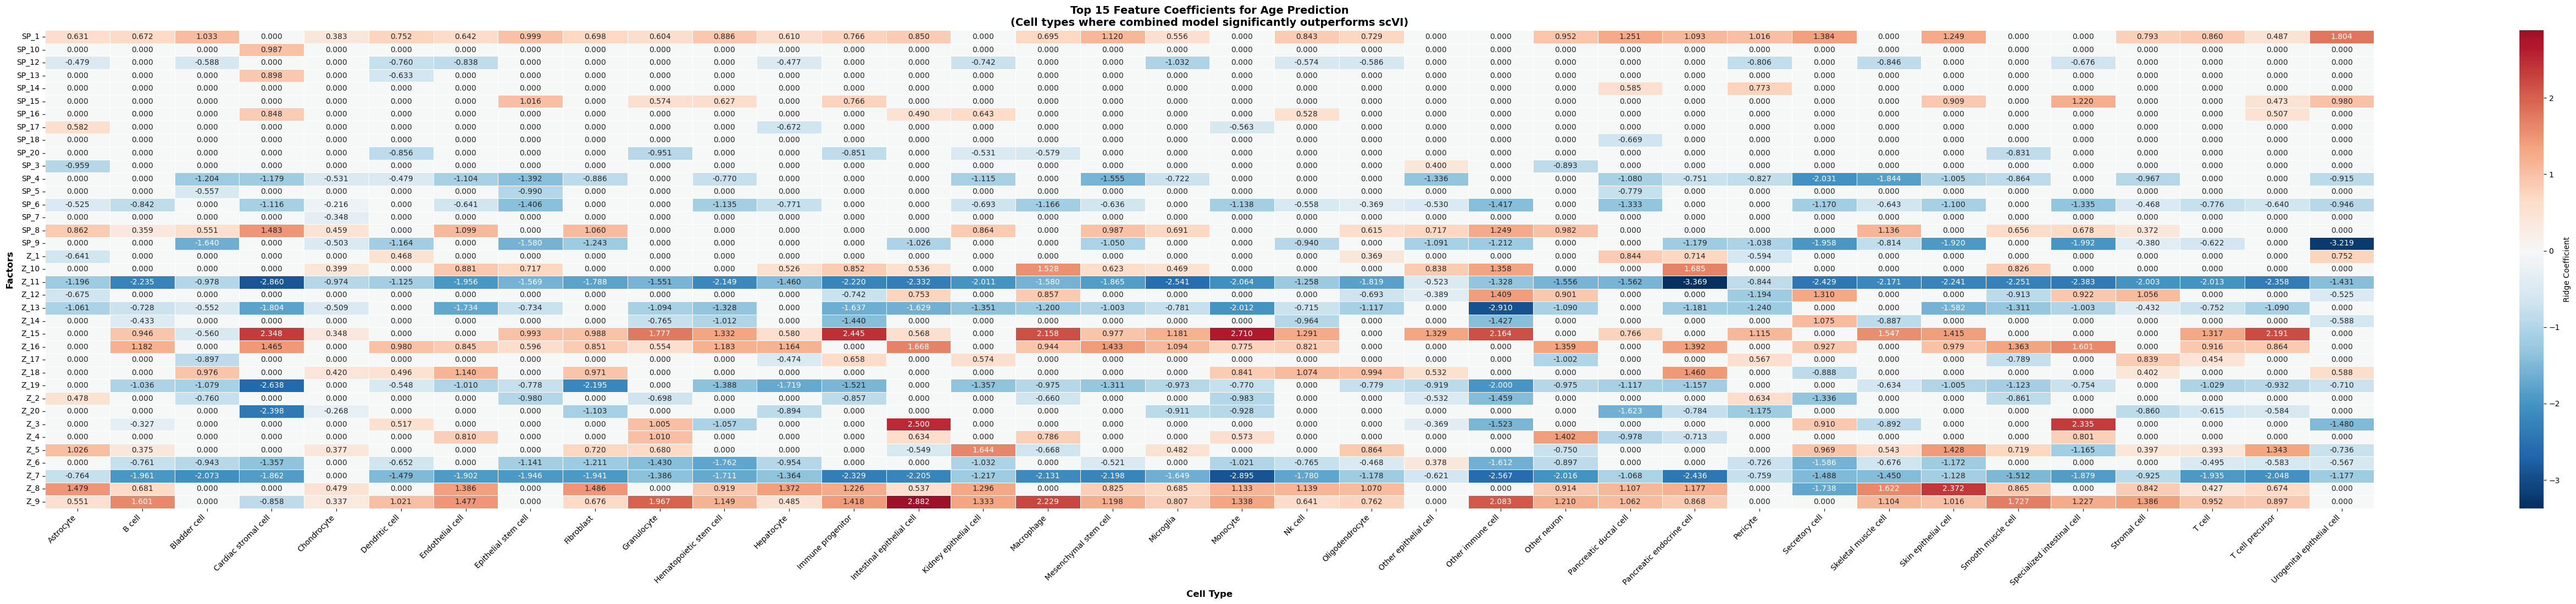

Saved heatmap to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-08-01/2025-08-03/param_id_0/analysis_outputs/feature_importance_heatmap.pdf
Creating splicing vs gene expression comparison...


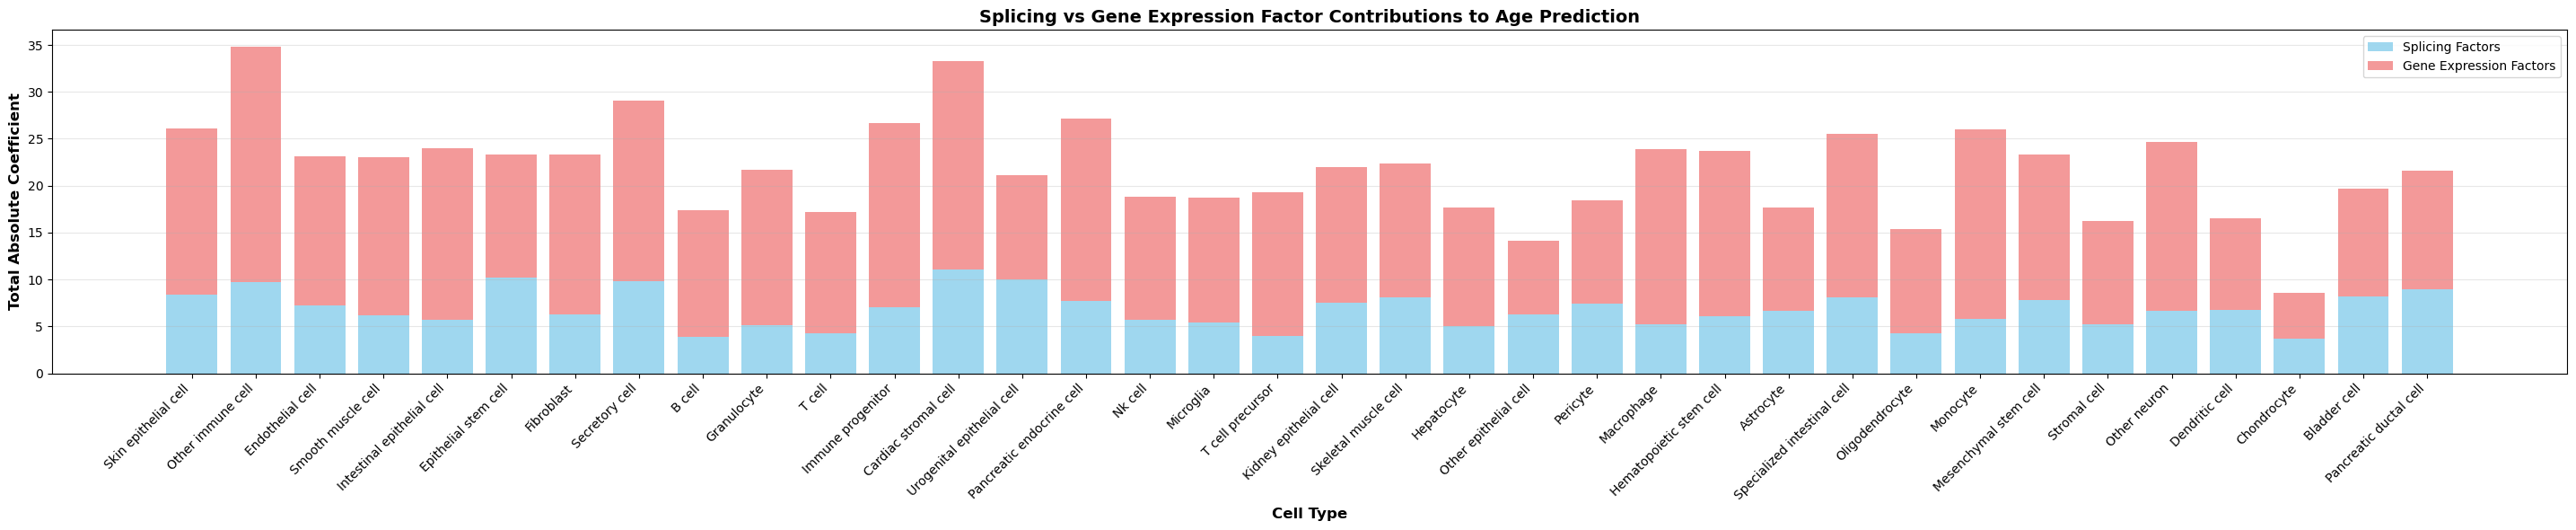

Saved contribution plot to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-08-01/2025-08-03/param_id_0/analysis_outputs/splicing_vs_gene_expression_contributions.pdf
Creating individual cell type plots...


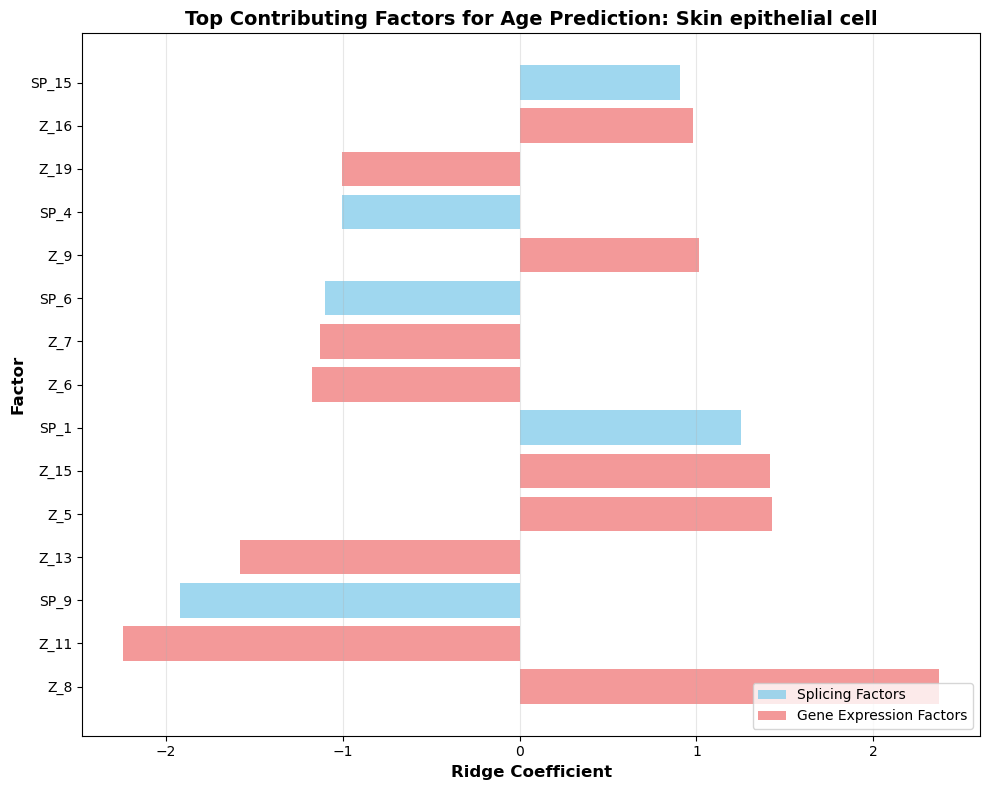

Saved individual plot for Skin epithelial cell


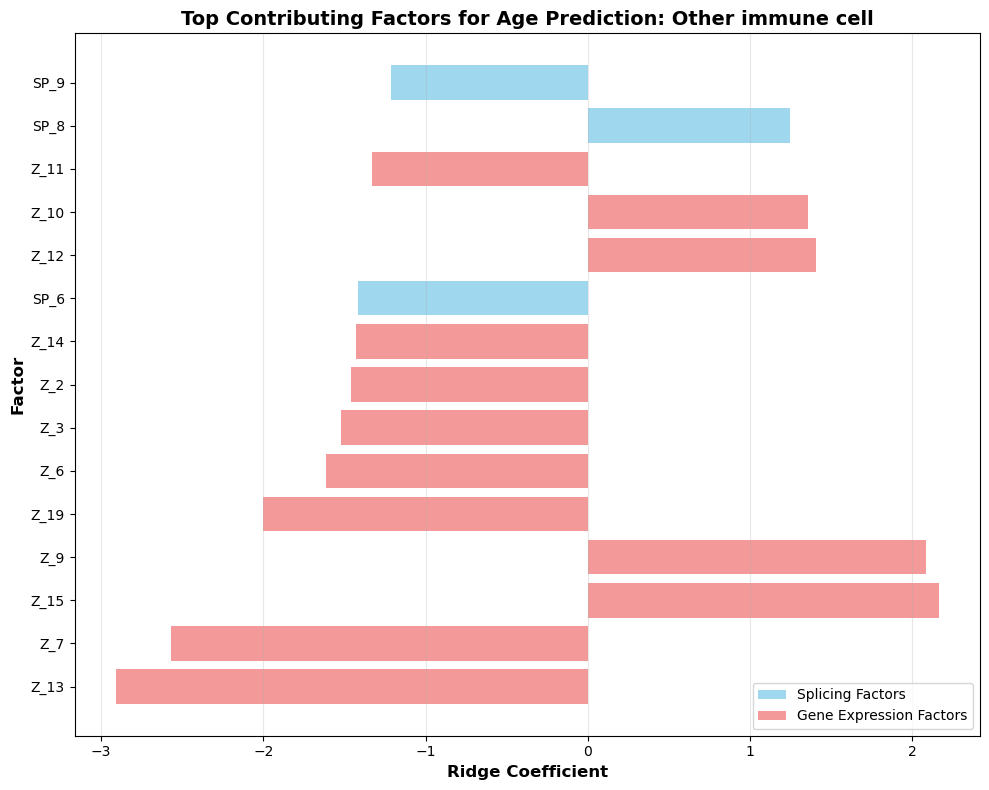

Saved individual plot for Other immune cell


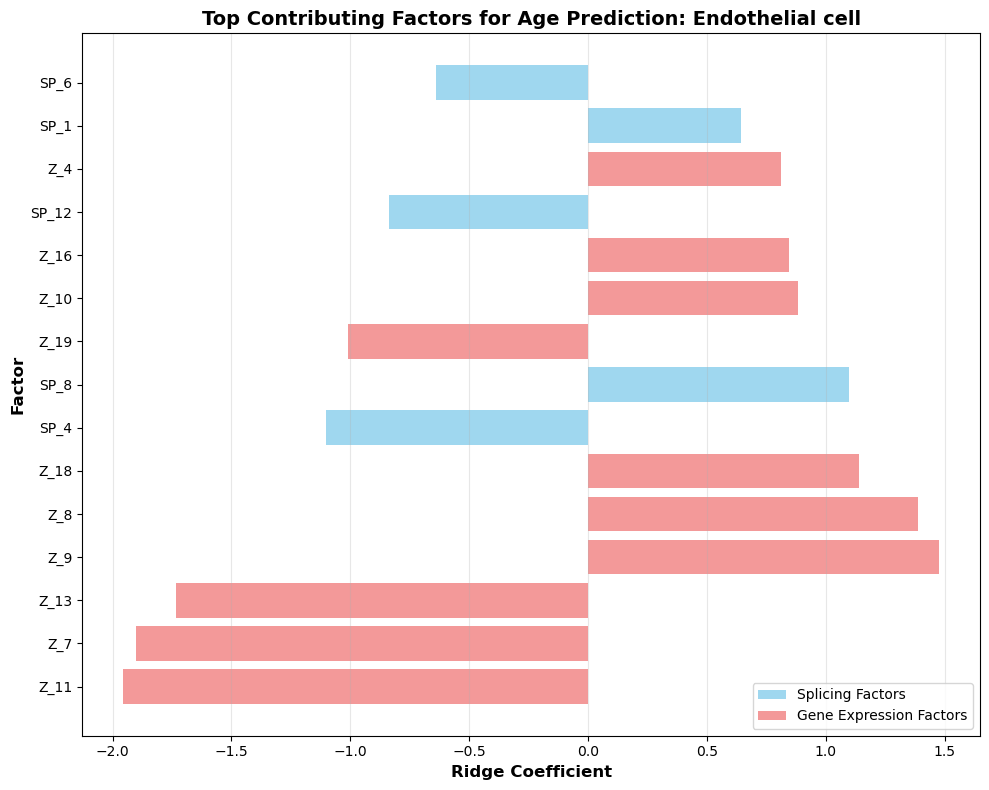

Saved individual plot for Endothelial cell
Detailed feature importance saved to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-08-01/2025-08-03/param_id_0/analysis_outputs/feature_importance_detailed.csv
Contribution summary saved to: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-08-01/2025-08-03/param_id_0/analysis_outputs/contribution_summary.csv

=== Feature Importance Summary ===
Analyzed 36 cell types with significant combined models

Splicing vs Gene Expression Contributions:
  Skin epithelial cell: 32.3% splicing, 67.7% gene expression
  Other immune cell: 27.8% splicing, 72.2% gene expression
  Endothelial cell: 31.3% splicing, 68.7% gene expression
  Smooth muscle cell: 27.1% splicing, 72.9% gene expression
  Intestinal epithelial cell: 23.8% splicing, 76.2% gene expression
  Epithelial stem cell: 43.6% splicing, 56.4% gene expression
  Fibroblast: 

In [24]:
if len(significant_celltypes) > 0:
    # Create feature importance visualizations
    contrib_summary = create_feature_importance_plots(
        sig_feature_df, significant_celltypes, OUTPUT_DIR, top_n=15
    )
    
    # Save detailed results
    feature_path = os.path.join(OUTPUT_DIR, "feature_importance_detailed.csv")
    sig_feature_df.to_csv(feature_path, index=False)
    print(f"Detailed feature importance saved to: {feature_path}")
    
    contrib_path = os.path.join(OUTPUT_DIR, "contribution_summary.csv")
    contrib_summary.to_csv(contrib_path, index=False)
    print(f"Contribution summary saved to: {contrib_path}")
    
    # Print summary
    print("\n=== Feature Importance Summary ===")
    print(f"Analyzed {len(significant_celltypes)} cell types with significant combined models")
    print("\nSplicing vs Gene Expression Contributions:")
    for _, row in contrib_summary.iterrows():
        print(f"  {row['cell_type']}: {row['splicing_fraction']:.1%} splicing, {row['gene_expression_fraction']:.1%} gene expression")
    
else:
    print("No cell types showed significant improvement with combined model over scVI alone.")

print("\nAnalysis complete!")